In [1]:
using Random
using Printf
using Plots


In [2]:
abstract type CoolingSchedule end

struct GeometricCooling <: CoolingSchedule
    T0::Float64
    alpha::Float64
end

struct LogarithmicCooling <: CoolingSchedule
    T0::Float64
end

struct SuperFastCooling <: CoolingSchedule
    T0::Float64
    beta::Float64
    d::Int
end

temperature(s::GeometricCooling, t::Int) = s.T0 * (s.alpha^(t - 1))
temperature(s::LogarithmicCooling, t::Int) = s.T0 / log(t + 1)
temperature(s::SuperFastCooling, t::Int) = s.T0 * exp(-s.beta * (t^(1.0 / s.d)))

metropolis_accept(Δ::Float64, T::Float64, rng::AbstractRNG) = (Δ <= 0) || (rand(rng) < exp(-Δ / T))


metropolis_accept (generic function with 1 method)

In [3]:
phi_example(x::Int) = (x^2 - 4)^2 + 0.5*x

function reflect_int(x::Int, lo::Int, hi::Int)
    if x < lo
        return lo + (lo - x)
    elseif x > hi
        return hi - (x - hi)
    end
    return x
end

function simulated_annealing_discrete(phi, x0::Int;
    schedule::CoolingSchedule,
    max_iter::Int = 20_000,
    T_min::Float64 = 1e-8,
    stall_iters::Int = 2_000,
    lo::Int = -5,
    hi::Int = 5,
    rng::AbstractRNG = Random.default_rng()
)
    x = x0
    fx = float(phi(x))

    best_x = x
    best_f = fx

    traj = Int[]
    push!(traj, x)

    best_f_hist = Float64[]
    push!(best_f_hist, best_f)

    last_improve = 0
    t_start = time_ns()

    for t in 1:max_iter
        T = temperature(schedule, t)
        if !(isfinite(T)) || T <= T_min
            break
        end

        step = rand(rng, Bool) ? 1 : -1
        x_new = reflect_int(x + step, lo, hi)
        f_new = float(phi(x_new))
        Δ = f_new - fx

        if metropolis_accept(Δ, T, rng)
            x = x_new
            fx = f_new
            push!(traj, x)
        end

        if fx < best_f - 1e-12
            best_f = fx
            best_x = x
            last_improve = t
        end

        push!(best_f_hist, best_f)

        if (t - last_improve) >= stall_iters
            break
        end
    end

    elapsed_s = (time_ns() - t_start) / 1e9
    return (best_x = best_x, best_f = best_f, traj = traj, best_f_hist = best_f_hist, elapsed_s = elapsed_s)
end


simulated_annealing_discrete (generic function with 1 method)

In [4]:
Random.seed!(42)

geom_1d = GeometricCooling(20.0, 0.9)
log_1d  = LogarithmicCooling(20.0)
sup_1d  = SuperFastCooling(20.0, 0.25, 1)

x0_1d = 4

# прогрев JIT
simulated_annealing_discrete(phi_example, x0_1d; schedule=geom_1d, max_iter=50)

res_geom_1d = simulated_annealing_discrete(phi_example, x0_1d; schedule=geom_1d)
res_log_1d  = simulated_annealing_discrete(phi_example, x0_1d; schedule=log_1d)
res_sup_1d  = simulated_annealing_discrete(phi_example, x0_1d; schedule=sup_1d)


(best_x = 2, best_f = 1.0, traj = [4, 3, 2], best_f_hist = [146.0, 26.5, 26.5, 26.5, 26.5, 26.5, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], elapsed_s = 7.0e-6)

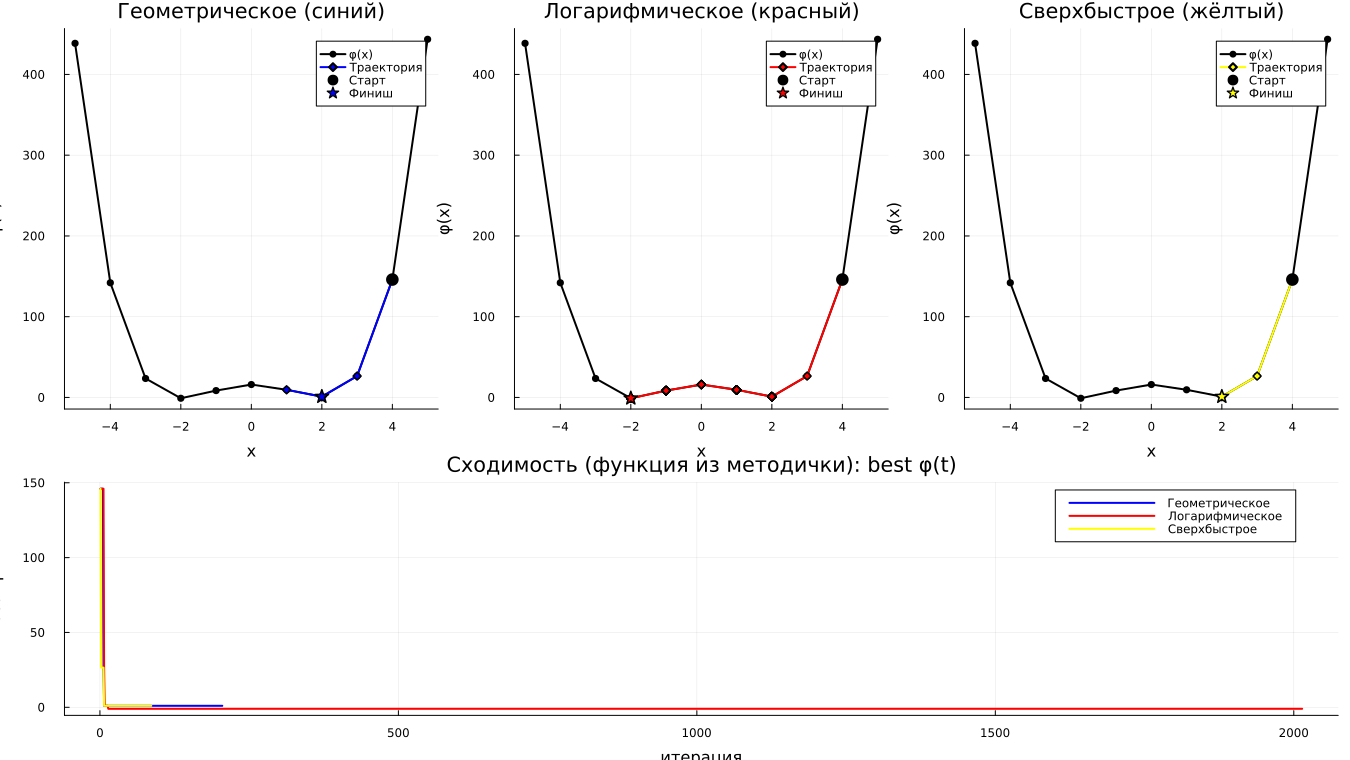

Время сходимости (функция из методички)
- Геометрическое (синий): 0.0000 сек, x=2, φ=1.000000
- Логарифмическое (красный): 0.0001 сек, x=-2, φ=-1.000000
- Сверхбыстрое (жёлтый): 0.0000 сек, x=2, φ=1.000000


In [5]:
xs_all = collect(-5:5)
ys_all = [phi_example(x) for x in xs_all]
phi_traj(traj) = [phi_example(x) for x in traj]

function plot_1d_method(xs_all, ys_all, x0, res; color, title)
    p = plot(xs_all, ys_all;
        color=:black,
        lw=2,
        marker=:circle,
        label="φ(x)",
        title=title,
        xlabel="x",
        ylabel="φ(x)",
        legend=:topright
    )
    plot!(p, res.traj, phi_traj(res.traj); color=color, lw=2, marker=:diamond, label="Траектория")
    scatter!(p, [x0], [phi_example(x0)]; color=:black, ms=7, label="Старт")
    scatter!(p, [res.best_x], [phi_example(res.best_x)]; color=color, ms=7, marker=:star5, label="Финиш")
    return p
end

p_geom = plot_1d_method(xs_all, ys_all, x0_1d, res_geom_1d; color=:blue,   title="Геометрическое (синий)")
p_log  = plot_1d_method(xs_all, ys_all, x0_1d, res_log_1d;  color=:red,    title="Логарифмическое (красный)")
p_sup  = plot_1d_method(xs_all, ys_all, x0_1d, res_sup_1d;  color=:yellow, title="Сверхбыстрое (жёлтый)")

p_all = plot(p_geom, p_log, p_sup; layout=(1, 3), size=(1350, 380))

p_conv_1d = plot(1:length(res_geom_1d.best_f_hist), res_geom_1d.best_f_hist;
    color=:blue, lw=2, label="Геометрическое",
    title="Сходимость (функция из методички): best φ(t)",
    xlabel="итерация",
    ylabel="best φ"
)
plot!(p_conv_1d, 1:length(res_log_1d.best_f_hist), res_log_1d.best_f_hist;  color=:red,    lw=2, label="Логарифмическое")
plot!(p_conv_1d, 1:length(res_sup_1d.best_f_hist), res_sup_1d.best_f_hist;  color=:yellow, lw=2, label="Сверхбыстрое")

p_block_1d = plot(p_all, p_conv_1d; layout=@layout([a{0.62h}; b{0.38h}]), size=(1350, 760))
display(p_block_1d)

@printf("Время сходимости (функция из методички)\n")
@printf("- Геометрическое (синий): %.4f сек, x=%d, φ=%.6f\n", res_geom_1d.elapsed_s, res_geom_1d.best_x, res_geom_1d.best_f)
@printf("- Логарифмическое (красный): %.4f сек, x=%d, φ=%.6f\n", res_log_1d.elapsed_s,  res_log_1d.best_x,  res_log_1d.best_f)
@printf("- Сверхбыстрое (жёлтый): %.4f сек, x=%d, φ=%.6f\n", res_sup_1d.elapsed_s,  res_sup_1d.best_x,  res_sup_1d.best_f)
nothing


In [6]:
function f_himmelblau(x)
    X, Y = x[1], x[2]
    return (X^2 + Y - 11)^2 + (X + Y^2 - 7)^2
end

function simulated_annealing_continuous(f, x0::AbstractVector{<:Real};
    schedule::CoolingSchedule,
    max_iter::Int = 120_000,
    T_min::Float64 = 1e-8,
    stall_iters::Int = 7_000,
    step0::Float64 = 0.9,
    bounds = ((-6.0, 6.0), (-6.0, 6.0)),
    rng::AbstractRNG = Random.default_rng()
)
    x = Float64.(x0)
    fx = f(x)

    best_x = copy(x)
    best_f = fx

    traj = Vector{Vector{Float64}}()
    push!(traj, copy(x))

    best_f_hist = Float64[]
    push!(best_f_hist, best_f)

    last_improve = 0
    t_start = time_ns()

    for t in 1:max_iter
        T = temperature(schedule, t)
        if !(isfinite(T)) || T <= T_min
            break
        end

        σ = step0 * sqrt(max(T / temperature(schedule, 1), 1e-12))
        x_new = x .+ σ .* randn(rng, length(x))

        for i in 1:length(x_new)
            lo, hi = bounds[i]
            x_new[i] = clamp(x_new[i], lo, hi)
        end

        f_new = f(x_new)
        Δ = f_new - fx

        if metropolis_accept(Δ, T, rng)
            x = x_new
            fx = f_new
            push!(traj, copy(x))
        end

        if fx < best_f - 1e-12
            best_f = fx
            best_x = copy(x)
            last_improve = t
        end

        push!(best_f_hist, best_f)

        if (t - last_improve) >= stall_iters
            break
        end
    end

    elapsed_s = (time_ns() - t_start) / 1e9
    return (best_x = best_x, best_f = best_f, traj = traj, best_f_hist = best_f_hist, elapsed_s = elapsed_s)
end


simulated_annealing_continuous (generic function with 1 method)

In [7]:
Random.seed!(42)

geom_2d = GeometricCooling(2.0, 0.9993)
log_2d  = LogarithmicCooling(2.0)
sup_2d  = SuperFastCooling(2.0, 0.06, 2)

x0_2d = [-4.5, 4.0]

# прогрев JIT
simulated_annealing_continuous(f_himmelblau, x0_2d; schedule=geom_2d, max_iter=50)

res_geom_2d = simulated_annealing_continuous(f_himmelblau, x0_2d; schedule=geom_2d)
res_log_2d  = simulated_annealing_continuous(f_himmelblau, x0_2d; schedule=log_2d)
res_sup_2d  = simulated_annealing_continuous(f_himmelblau, x0_2d; schedule=sup_2d)


(best_x = [-2.8058719736586903, 3.1321411157352737], best_f = 4.526797620701243e-5, traj = [[-4.5, 4.0], [-3.24472883467317, 3.1186297326143717], [-2.4603483662872345, 3.091747930090934], [-2.4547457863164848, 3.130760089400119], [-2.679192182309984, 2.847609677090988], [-2.68904392191833, 3.03747076378081], [-2.7156401514206685, 3.239255500875009], [-2.845204559858333, 3.041911233571911], [-2.9016361431039557, 3.1112735144745534], [-2.8256213181989107, 3.0525766509162495]  …  [-2.807652523086371, 3.1287652657990006], [-2.8076941930133192, 3.1265403794107995], [-2.808302963998798, 3.1355742021425352], [-2.808039861529869, 3.122665504168999], [-2.813001521752537, 3.1247259985000424], [-2.8029026342939427, 3.1341586657608644], [-2.8089474392927074, 3.130924580801223], [-2.8073346873138916, 3.1345632301786637], [-2.8061999628478307, 3.1293664475906113], [-2.810710708762053, 3.1332775138910116]], best_f_hist = [195.8125, 7.275286622920749, 7.275286622920749, 7.275286622920749, 7.2752866229

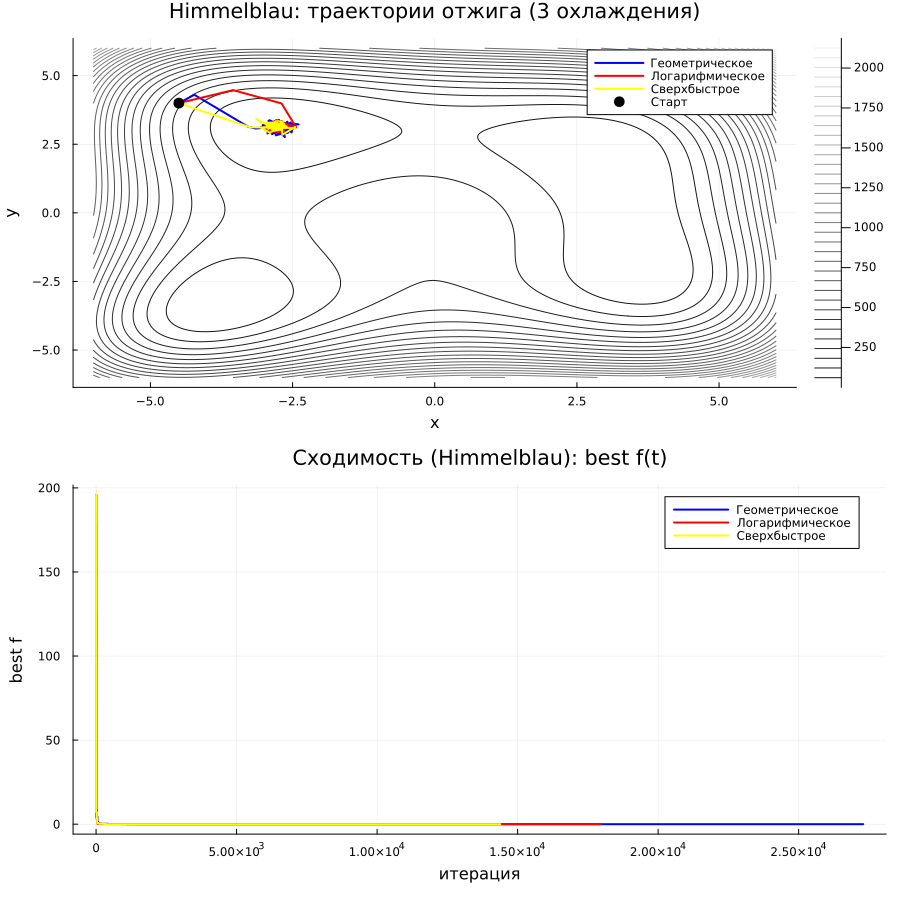

Время сходимости (Himmelblau)
- Геометрическое (синий): 0.0040 сек, x=(-2.8051, 3.1313), f=0.000000
- Логарифмическое (красный): 0.0022 сек, x=(-2.8074, 3.1335), f=0.000359
- Сверхбыстрое (жёлтый): 0.0159 сек, x=(-2.8059, 3.1321), f=0.000045


In [8]:
traj_xy(traj) = ([p[1] for p in traj], [p[2] for p in traj])

xgrid = range(-6, 6, length=250)
ygrid = range(-6, 6, length=250)
Z = [f_himmelblau([x, y]) for y in ygrid, x in xgrid]

p2 = contour(
    xgrid, ygrid, Z;
    levels=35,
    c=:grays,
    linewidth=1,
    title="Himmelblau: траектории отжига (3 охлаждения)",
    xlabel="x",
    ylabel="y",
    legend=:topright
)

xg, yg = traj_xy(res_geom_2d.traj)
xl, yl = traj_xy(res_log_2d.traj)
xs, ys = traj_xy(res_sup_2d.traj)

plot!(p2, xg, yg; color=:blue,   lw=2, label="Геометрическое")
plot!(p2, xl, yl; color=:red,    lw=2, label="Логарифмическое")
plot!(p2, xs, ys; color=:yellow, lw=2, label="Сверхбыстрое")

scatter!(p2, [x0_2d[1]], [x0_2d[2]]; color=:black, ms=6, label="Старт")
p_conv_2d = plot(1:length(res_geom_2d.best_f_hist), res_geom_2d.best_f_hist;
    color=:blue, lw=2, label="Геометрическое",
    title="Сходимость (Himmelblau): best f(t)",
    xlabel="итерация",
    ylabel="best f"
)
plot!(p_conv_2d, 1:length(res_log_2d.best_f_hist), res_log_2d.best_f_hist;  color=:red,    lw=2, label="Логарифмическое")
plot!(p_conv_2d, 1:length(res_sup_2d.best_f_hist), res_sup_2d.best_f_hist;  color=:yellow, lw=2, label="Сверхбыстрое")

p_block_2d = plot(p2, p_conv_2d; layout=(2,1), size=(900, 900))
display(p_block_2d)

@printf("Время сходимости (Himmelblau)\n")
@printf("- Геометрическое (синий): %.4f сек, x=(%.4f, %.4f), f=%.6f\n", res_geom_2d.elapsed_s, res_geom_2d.best_x[1], res_geom_2d.best_x[2], res_geom_2d.best_f)
@printf("- Логарифмическое (красный): %.4f сек, x=(%.4f, %.4f), f=%.6f\n", res_log_2d.elapsed_s,  res_log_2d.best_x[1],  res_log_2d.best_x[2],  res_log_2d.best_f)
@printf("- Сверхбыстрое (жёлтый): %.4f сек, x=(%.4f, %.4f), f=%.6f\n", res_sup_2d.elapsed_s,  res_sup_2d.best_x[1],  res_sup_2d.best_x[2],  res_sup_2d.best_f)
nothing
